# 3-2 DB 보정 버전

이 노트북은 `3-1_openCV_test.ipynb`의 실시간 OpenCV 흐름을 유지하면서, `compare_prompt.md` 요구사항에 맞춰 0.2초 간격 샘플 15개 단위 후처리, SQLite 저장, 연속 상태 경고, 세션 요약 통계를 추가한 버전입니다.

## 전체 흐름

1. 웹캠 프레임을 읽고 MediaPipe로 얼굴 영역을 찾습니다.
2. 기존 모델이 프레임마다 `Attentive`, `LookingAway`, `Drowsy` 확률을 예측합니다.
3. 매 프레임 화면 확률은 갱신하되, DB/State 판단용 결과는 `SAMPLE_INTERVAL_SEC = 0.2`초마다 1개씩 `WINDOW_SIZE = 15`개를 모읍니다.
4. `decide_state()`가 threshold 규칙으로 최종 상태를 보정합니다.
5. 보정된 최종 상태 1건만 SQLite DB의 `attention_logs`에 저장합니다.
6. 최근 3개 결과가 모두 `Drowsy` 또는 모두 `LookingAway`일 때만 경고를 출력합니다.
7. 종료 시 DB에 저장된 결과를 기준으로 수업 전체 집중 통계를 계산합니다.


## Cell 1. 공통 import와 모델 로딩 함수

이 셀은 기존 `3-1_openCV_test.ipynb`의 기본 구조를 유지하는 부분입니다. 일반적으로 이 셀은 수정하지 않아도 됩니다.

수정이 필요한 경우:

- 모델 파일 폴더를 바꾸고 싶으면 `model_dir = Path("models")`를 수정합니다.
- 새로운 torchvision 모델을 추가하려면 `model_list`에 모델 생성 함수와 마지막 layer 교체 함수를 추가합니다.
- checkpoint 저장 키가 달라졌다면 `get_class_names()` 또는 `get_model_state()`를 수정합니다.


In [37]:
# Cell 1 코드: 공통 import, 모델 생성 함수, checkpoint 로딩 함수
from pathlib import Path
from datetime import datetime, timezone
import sqlite3
import time
import uuid

import cv2
import mediapipe as mp
import numpy as np
import torch
from torch import nn
from PIL import Image
from torchvision import models, transforms

model_dir = Path("models")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def make_eval_transform(image_size: int):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def change_fc(model, class_count: int):
    model.fc = nn.Linear(model.fc.in_features, class_count)
    return model

def change_classifier(model, class_count: int):
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, class_count)
    return model

model_list = {
    "resnet18": [models.resnet18, change_fc],
    "resnet34": [models.resnet34, change_fc],
    "resnet50": [models.resnet50, change_fc],
    "mobilenet_v3_large": [models.mobilenet_v3_large, change_classifier],
    "efficientnet_b0": [models.efficientnet_b0, change_classifier],
    "efficientnet_b2": [models.efficientnet_b2, change_classifier],
    "efficientnet_b3": [models.efficientnet_b3, change_classifier],
    "efficientnet_v2_s": [models.efficientnet_v2_s, change_classifier],
}

def infer_model_name(path: Path, checkpoint: dict):
    if "model_name" in checkpoint:
        return checkpoint["model_name"]
    return path.stem.removesuffix("_best")

def load_checkpoint(path: Path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)

def get_class_names(checkpoint: dict):
    if "class_names" in checkpoint:
        return list(checkpoint["class_names"])
    if "class_to_idx" in checkpoint:
        return [name for name, _ in sorted(checkpoint["class_to_idx"].items(), key=lambda item: item[1])]
    raise KeyError("checkpoint is missing class_names or class_to_idx")

def get_model_state(checkpoint: dict):
    if "model_state" in checkpoint:
        return checkpoint["model_state"]
    if "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    raise KeyError("checkpoint is missing model_state or model_state_dict")

def create_model(model_name: str, class_count: int):
    if model_name not in model_list:
        raise ValueError(f"unsupported model name: {model_name}")

    model_func, change_last_layer = model_list[model_name]
    model = model_func(weights=None)
    model = change_last_layer(model, class_count)
    return model


device: cuda


## Cell 2. 후처리/DB/경고 설정값

아래 코드 셀에서 가장 자주 바꿀 값은 상단의 상수들입니다. 모델 로딩이나 웹캠 코드는 최대한 그대로 두고, 판단 민감도는 이 값들만 조정하는 것을 권장합니다.

| 설정값 | 현재 추천값 | 언제 바꾸나 | 조정 방향 |
|---|---:|---|---|
| `WINDOW_SIZE` | `15` | 최종 판단에 사용할 샘플 수 | 더 안정적으로 보려면 증가, 더 빠르게 반응하려면 감소 |
| `SAMPLE_INTERVAL_SEC` | `0.2` | 판단용 샘플 간격(초) | 더 촘촘히 보려면 감소, 더 듬성듬성 보려면 증가 |
| `MIN_FRAMES_FOR_DECISION` | `5` | 프레임이 너무 적을 때 판단을 막는 최소값 | 초반 판단이 너무 빨리 나오면 증가 |
| `ATTENTIVE_FRAME_THRESHOLD` | `0.35` | 한 샘플을 집중으로 인정할 확률 기준 | 집중 보호가 너무 강하면 증가, 너무 약하면 감소 |
| `ATTENTIVE_MIN_COUNT` | `5` | 15개 샘플 중 집중으로 인정할 최소 샘플 수 | 집중으로 너무 자주 보정되면 증가 |
| `LOOKING_AWAY_MIN_COUNT` | `10` | 시선 이탈 확정에 필요한 최소 프레임 수 | 오탐을 더 줄이려면 증가 |
| `LOOKING_AWAY_AVG_THRESHOLD` | `0.70` | 시선 이탈 평균 확률 기준 | 시선 이탈이 너무 자주 뜨면 증가 |
| `DROWSY_MIN_COUNT` | `8` | 졸음 확정에 필요한 최소 프레임 수 | 졸음 감지를 더 민감하게 하려면 감소 |
| `DROWSY_AVG_THRESHOLD` | `0.60` | 졸음 평균 확률 기준 | 졸음 오탐이 많으면 증가 |
| `RECENT_STATE_PRINT_COUNT` | `3` | 콘솔에 함께 출력할 최근 State 개수 | 출력 맥락만 바꾸고 판단에는 영향 없음 |

추천값은 현재 요구사항 기준의 시작점입니다. 실제 카메라/조명/학생 자세 데이터로 테스트하면서 `LookingAway` 오탐이 많으면 `LOOKING_AWAY_*` 값을 올리고, 졸음을 놓치면 `DROWSY_*` 값을 조금 낮추는 방식으로 조정하세요.


In [38]:
from collections import Counter, deque

# =========================
# 1. DB 저장 위치
# =========================
# 추천값: attention_logs.db
# 바꾸는 경우: 결과 DB 파일명을 날짜별/실험별로 나누고 싶을 때만 변경합니다.
DB_PATH = Path("attention_logs.db")

# =========================
# 2. 0.2초 간격 샘플 15개 판단 단위
# =========================
# 추천값: 15
# 의미: 모델 예측을 0.2초마다 1개씩 샘플링하고, 15개가 모이면 최종 상태 1개로 보정합니다.
# 조정: 결과가 너무 흔들리면 20~30으로 증가, 반응이 너무 느리면 10으로 감소합니다.
WINDOW_SIZE = 15
SAMPLE_INTERVAL_SEC = 0.2

# 추천값: 5
# 의미: 프레임이 너무 적을 때 억지 판단하지 않고 기본 Attentive로 처리하기 위한 최소 프레임 수입니다.
MIN_FRAMES_FOR_DECISION = 5

# =========================
# 3. Attentive 보호 규칙
# =========================
# 추천값: 0.60 / 8 / 0.55 / 7
# 의미: 일부 프레임에서 LookingAway가 높게 나와도, 집중 프레임이 충분하면 최종 결과를 Attentive로 보정합니다.
# 조정: Attentive로 너무 많이 보정되면 MIN_COUNT나 AVG_THRESHOLD를 올립니다.
ATTENTIVE_FRAME_THRESHOLD = 0.35
ATTENTIVE_MIN_COUNT = 5

# =========================
# 4. LookingAway 확정 규칙
# =========================
# 추천값: 0.65 / 10 / 0.70
# 의미: 시선 이탈은 일시적인 고개 움직임으로 오탐이 많을 수 있으므로 엄격하게 확정합니다.
# 조정: 시선 이탈 오탐이 많으면 MIN_COUNT를 11~12 또는 AVG_THRESHOLD를 0.75로 올립니다.
LOOKING_AWAY_FRAME_THRESHOLD = 0.55
LOOKING_AWAY_MIN_COUNT = 10
LOOKING_AWAY_AVG_THRESHOLD = 0.55

# =========================
# 5. Drowsy 확정 규칙
# =========================
# 추천값: 0.60 / 8 / 0.60
# 의미: 졸음은 중요한 상태라 LookingAway보다 조금 더 민감하게 확정합니다.
# 조정: 졸음을 놓치면 MIN_COUNT를 7로 낮추고, 오탐이 많으면 AVG_THRESHOLD를 0.65로 올립니다.
DROWSY_FRAME_THRESHOLD = 0.50
DROWSY_MIN_COUNT = 6
DROWSY_AVG_THRESHOLD = 0.50

# =========================
# 6. 얼굴 없음/불확실 샘플 허용 개수
# =========================
# 추천값: 각각 5
# 의미: 15개 샘플 중 얼굴 없음 또는 불확실 샘플이 너무 많으면 최종 상태를 Unknown으로 처리합니다.
NO_FACE_ALLOWED_COUNT = 5
UNCERTAIN_ALLOWED_COUNT = 5

# =========================
# 7. 경고 발생 규칙
# =========================
# 추천값: 3
# 의미: 콘솔 로그에 함께 보여줄 최근 State 개수입니다. Warning 판단에는 사용하지 않습니다.
RECENT_STATE_PRINT_COUNT = 3

CLASS_ALIASES = {
    "attentive": "Attentive",
    "lookingaway": "LookingAway",
    "looking_away": "LookingAway",
    "looking away": "LookingAway",
    "drowsy": "Drowsy",
    "noface": "NoFace",
    "no_face": "NoFace",
    "no face": "NoFace",
    "uncertain": "Uncertain",
    "unknown": "Unknown",
}
VALID_STATES = ["Attentive", "LookingAway", "Drowsy"]


def utc_now_iso():
    return datetime.now(timezone.utc).isoformat(timespec="seconds")


def normalize_class_name(name):
    key = str(name).strip().replace("-", "_").lower()
    return CLASS_ALIASES.get(key, str(name).strip())


def normalize_frame_probs(frame_prob):
    normalized = {state: 0.0 for state in VALID_STATES}
    invalid_state = None

    for key, value in dict(frame_prob).items():
        class_name = normalize_class_name(key)
        if class_name in VALID_STATES:
            normalized[class_name] = float(value)
        elif class_name in {"NoFace", "Uncertain", "Unknown"} and float(value) > 0:
            invalid_state = class_name

    return normalized, invalid_state


def decide_state(frame_probs, return_debug=False):
    """0.2초 간격 샘플 15개를 threshold 규칙으로 보정해 최종 상태를 반환합니다."""
    frame_probs = list(frame_probs)[-WINDOW_SIZE:]

    if len(frame_probs) < MIN_FRAMES_FOR_DECISION:
        debug_info = {
            "attentive_avg": 0.0,
            "lookingaway_avg": 0.0,
            "drowsy_avg": 0.0,
            "attentive_count": 0,
            "lookingaway_count": 0,
            "drowsy_count": 0,
            "argmax_result": "Unknown",
            "final_state": "Attentive",
            "reason": "프레임 수 부족: 기본 Attentive 처리",
            "valid_frame_count": 0,
            "no_face_count": 0,
            "uncertain_count": 0,
        }
        return ("Attentive", debug_info) if return_debug else "Attentive"

    valid_probs = []
    invalid_counter = Counter()
    argmax_votes = Counter()

    for frame_prob in frame_probs:
        normalized, invalid_state = normalize_frame_probs(frame_prob)
        if invalid_state in {"NoFace", "Uncertain", "Unknown"}:
            invalid_counter[invalid_state] += 1
            continue

        valid_probs.append(normalized)
        argmax_votes[max(VALID_STATES, key=lambda state: normalized[state])] += 1

    no_face_count = invalid_counter["NoFace"]
    uncertain_count = invalid_counter["Uncertain"] + invalid_counter["Unknown"]

    if no_face_count > NO_FACE_ALLOWED_COUNT or uncertain_count > UNCERTAIN_ALLOWED_COUNT:
        final_state = "Unknown"
        reason = "얼굴 없음/불확실 프레임 과다: Unknown 처리"
        argmax_result = argmax_votes.most_common(1)[0][0] if argmax_votes else "Unknown"
        debug_info = {
            "attentive_avg": 0.0,
            "lookingaway_avg": 0.0,
            "drowsy_avg": 0.0,
            "attentive_count": 0,
            "lookingaway_count": 0,
            "drowsy_count": 0,
            "argmax_result": argmax_result,
            "final_state": final_state,
            "reason": reason,
            "valid_frame_count": len(valid_probs),
            "no_face_count": no_face_count,
            "uncertain_count": uncertain_count,
        }
        return (final_state, debug_info) if return_debug else final_state

    if not valid_probs:
        final_state = "Unknown"
        debug_info = {
            "attentive_avg": 0.0,
            "lookingaway_avg": 0.0,
            "drowsy_avg": 0.0,
            "attentive_count": 0,
            "lookingaway_count": 0,
            "drowsy_count": 0,
            "argmax_result": "Unknown",
            "final_state": final_state,
            "reason": "유효한 확률 프레임 없음",
            "valid_frame_count": 0,
            "no_face_count": no_face_count,
            "uncertain_count": uncertain_count,
        }
        return (final_state, debug_info) if return_debug else final_state

    attentive_values = [prob["Attentive"] for prob in valid_probs]
    lookingaway_values = [prob["LookingAway"] for prob in valid_probs]
    drowsy_values = [prob["Drowsy"] for prob in valid_probs]

    attentive_avg = sum(attentive_values) / len(attentive_values)
    lookingaway_avg = sum(lookingaway_values) / len(lookingaway_values)
    drowsy_avg = sum(drowsy_values) / len(drowsy_values)

    attentive_count = sum(value >= ATTENTIVE_FRAME_THRESHOLD for value in attentive_values)
    lookingaway_count = sum(value >= LOOKING_AWAY_FRAME_THRESHOLD for value in lookingaway_values)
    drowsy_count = sum(value >= DROWSY_FRAME_THRESHOLD for value in drowsy_values)

    avg_by_state = {
        "Attentive": attentive_avg,
        "LookingAway": lookingaway_avg,
        "Drowsy": drowsy_avg,
    }
    argmax_result = max(avg_by_state, key=avg_by_state.get)

    if attentive_count >= ATTENTIVE_MIN_COUNT:
        final_state = "Attentive"
        reason = "At least 5 of 15 samples have Attentive probability >= 0.35"
    else:
        if lookingaway_avg >= drowsy_avg:
            final_state = "LookingAway"
        else:
            final_state = "Drowsy"
        reason = "Attentive is not strong enough; selected the higher non-attentive average"

    debug_info = {
        "attentive_avg": attentive_avg,
        "lookingaway_avg": lookingaway_avg,
        "drowsy_avg": drowsy_avg,
        "attentive_count": attentive_count,
        "lookingaway_count": lookingaway_count,
        "drowsy_count": drowsy_count,
        "argmax_result": argmax_result,
        "final_state": final_state,
        "reason": reason,
        "valid_frame_count": len(valid_probs),
        "no_face_count": no_face_count,
        "uncertain_count": uncertain_count,
    }
    return (final_state, debug_info) if return_debug else final_state


def init_db(db_path=DB_PATH):
    db_path = Path(db_path)
    with sqlite3.connect(db_path) as conn:
        conn.execute("""
            CREATE TABLE IF NOT EXISTS attention_logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                session_id TEXT NOT NULL,
                timestamp TEXT NOT NULL,
                final_state TEXT NOT NULL,
                argmax_result TEXT,
                attentive_avg REAL,
                lookingaway_avg REAL,
                drowsy_avg REAL,
                attentive_count INTEGER,
                lookingaway_count INTEGER,
                drowsy_count INTEGER,
                reason TEXT
            )
        """)
        conn.execute("""
            CREATE TABLE IF NOT EXISTS class_sessions (
                session_id TEXT PRIMARY KEY,
                started_at TEXT NOT NULL,
                ended_at TEXT,
                total_duration_sec REAL
            )
        """)
    return db_path


def create_session(db_path=DB_PATH):
    init_db(db_path)
    session_id = uuid.uuid4().hex
    with sqlite3.connect(db_path) as conn:
        conn.execute(
            "INSERT INTO class_sessions (session_id, started_at) VALUES (?, ?)",
            (session_id, utc_now_iso()),
        )
    return session_id


def save_attention_log(db_path, session_id, final_result, debug_info):
    init_db(db_path)
    with sqlite3.connect(db_path) as conn:
        conn.execute(
            """
            INSERT INTO attention_logs (
                session_id, timestamp, final_state, argmax_result,
                attentive_avg, lookingaway_avg, drowsy_avg,
                attentive_count, lookingaway_count, drowsy_count, reason
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
            """,
            (
                session_id,
                utc_now_iso(),
                final_result,
                debug_info.get("argmax_result"),
                debug_info.get("attentive_avg"),
                debug_info.get("lookingaway_avg"),
                debug_info.get("drowsy_avg"),
                debug_info.get("attentive_count"),
                debug_info.get("lookingaway_count"),
                debug_info.get("drowsy_count"),
                debug_info.get("reason"),
            ),
        )


def get_recent_states(db_path, session_id, limit=RECENT_STATE_PRINT_COUNT):
    init_db(db_path)
    with sqlite3.connect(db_path) as conn:
        rows = conn.execute(
            """
            SELECT final_state
            FROM attention_logs
            WHERE session_id = ?
            ORDER BY id DESC
            LIMIT ?
            """,
            (session_id, limit),
        ).fetchall()
    return [row[0] for row in reversed(rows)]


def check_warning(final_state, current_warning_message=None):
    if final_state == "Attentive":
        return None
    if final_state == "Drowsy":
        return "Drowsy state is continuing. Please sit up and refocus."
    if final_state == "LookingAway":
        return "Looking-away state is continuing. Please look back at the screen."
    return current_warning_message


def end_session(db_path, session_id):
    init_db(db_path)
    ended_at = utc_now_iso()
    with sqlite3.connect(db_path) as conn:
        row = conn.execute(
            "SELECT started_at FROM class_sessions WHERE session_id = ?",
            (session_id,),
        ).fetchone()
        total_duration_sec = None
        if row:
            started_at = datetime.fromisoformat(row[0])
            ended_dt = datetime.fromisoformat(ended_at)
            total_duration_sec = (ended_dt - started_at).total_seconds()
        conn.execute(
            "UPDATE class_sessions SET ended_at = ?, total_duration_sec = ? WHERE session_id = ?",
            (ended_at, total_duration_sec, session_id),
        )
    return total_duration_sec


def get_session_summary(db_path, session_id, exclude_unknown=True, fps=None):
    init_db(db_path)
    with sqlite3.connect(db_path) as conn:
        rows = conn.execute(
            "SELECT final_state FROM attention_logs WHERE session_id = ?",
            (session_id,),
        ).fetchall()

    counts = Counter(row[0] for row in rows)
    states_for_total = ["Attentive", "Drowsy", "LookingAway"] if exclude_unknown else ["Attentive", "Drowsy", "LookingAway", "Unknown"]
    valid_total = sum(counts[state] for state in states_for_total)

    rates = {
        state: (counts[state] / valid_total * 100.0 if valid_total else 0.0)
        for state in states_for_total
    }

    window_duration_sec = WINDOW_SIZE * SAMPLE_INTERVAL_SEC
    durations = {
        state: (counts[state] * window_duration_sec if window_duration_sec else None)
        for state in ["Attentive", "Drowsy", "LookingAway", "Unknown"]
    }

    return {
        "session_id": session_id,
        "total_logs": len(rows),
        "valid_total": valid_total,
        "counts": dict(counts),
        "rates": rates,
        "durations_sec": durations,
    }


def format_session_summary(summary):
    counts = summary["counts"]
    rates = summary["rates"]
    valid_total = summary["valid_total"]
    return (
        "전체 수업 집중도 요약\n\n"
        f"전체 유효 분석 구간: {valid_total}개\n"
        f"집중 상태: {counts.get('Attentive', 0)}개 ({rates.get('Attentive', 0.0):.1f}%)\n"
        f"졸음 상태: {counts.get('Drowsy', 0)}개 ({rates.get('Drowsy', 0.0):.1f}%)\n"
        f"시선 이탈 상태: {counts.get('LookingAway', 0)}개 ({rates.get('LookingAway', 0.0):.1f}%)\n"
        f"Unknown 상태: {counts.get('Unknown', 0)}개\n\n"
        f"이번 수업에서 전체 유효 분석 구간 중 {rates.get('Attentive', 0.0):.1f}% 동안 집중 상태를 유지했습니다."
    )


## Cell 3. 후처리 로직 빠른 테스트

웹캠을 열지 않고 `decide_state()`만 확인하는 셀입니다. 예제는 `LookingAway` 확률이 높은 샘플이 일부 있어도, 15개 샘플 중 `Attentive >= 0.60`인 샘플이 8개라 최종 결과가 `Attentive`로 보정되는 상황입니다.

이 셀에서 확인할 것:

- `argmax_result`: 단순 평균 argmax 결과
- `final_state`: threshold 보정 후 최종 결과
- `reason`: 최종 결과가 결정된 이유


In [39]:
# 예제 상황: 집중 프레임 8개 + 강한 LookingAway 프레임 5개 + 애매한 프레임 2개
sample_frames = []
for _ in range(8):
    sample_frames.append({"Attentive": 0.62, "LookingAway": 0.25, "Drowsy": 0.13})
for _ in range(5):
    sample_frames.append({"Attentive": 0.20, "LookingAway": 0.85, "Drowsy": 0.05})
for _ in range(2):
    sample_frames.append({"Attentive": 0.45, "LookingAway": 0.40, "Drowsy": 0.15})

final_state, debug_info = decide_state(sample_frames, return_debug=True)
print("최종 보정 결과:", final_state)
print("디버그 정보:")
for key, value in debug_info.items():
    print(f"  {key}: {value}")


최종 보정 결과: Attentive
디버그 정보:
  attentive_avg: 0.45733333333333337
  lookingaway_avg: 0.47
  drowsy_avg: 0.10600000000000001
  attentive_count: 10
  lookingaway_count: 5
  drowsy_count: 0
  argmax_result: LookingAway
  final_state: Attentive
  reason: At least 5 of 15 samples have Attentive probability >= 0.35
  valid_frame_count: 15
  no_face_count: 0
  uncertain_count: 0


## Cell 4. 실시간 OpenCV 실행 셀

이 셀은 실제 웹캠을 여는 실행 셀입니다. 위쪽 설정 셀을 먼저 실행한 뒤 이 셀을 실행하세요.

실행 전에 주로 바꿀 값:

| 설정값 | 추천값 | 설명 |
|---|---:|---|
| `realtime_model_name` | `resnet18` | 사용할 학습 모델 이름입니다. `models/{모델명}_best.pt` 파일이 있어야 합니다. |
| `camera_index` | `0` | 기본 웹캠입니다. 외장 카메라를 쓰면 `1`, `2` 등을 시도하세요. |
| `frame_width` / `frame_height` | `960` / `720` | 웹캠 입력 해상도입니다. 느리면 `640` / `480`으로 낮추세요. |
| `face_padding_ratio` | `0.25` | 얼굴 crop 주변 여백입니다. 얼굴 일부가 잘리면 `0.30` 정도로 올리세요. |
| `confidence_threshold` | `0.50` | 화면 표시용 Uncertain 기준입니다. DB 보정에는 raw 확률이 들어갑니다. |
| `margin_threshold` | `0.10` | 1등/2등 확률 차이가 작을 때 화면에 Uncertain으로 표시하는 기준입니다. |
| `SAMPLE_INTERVAL_SEC` | `0.2` | DB/State 판단용 샘플을 0.2초마다 1개씩 저장합니다. 15개가 모이면 약 3초 단위로 판단합니다. |

종료 방법: OpenCV 창에서 `q`를 누르면 세션 종료 시간이 DB에 저장되고 전체 요약이 출력됩니다.


In [40]:
# =========================
# 1. 실행할 모델 선택
# =========================
# 추천값: resnet18
# 바꾸는 경우: 다른 모델 성능을 실시간으로 비교하고 싶을 때 변경합니다.
# 사용 가능 예: resnet18, resnet34, resnet50, mobilenet_v3_large, efficientnet_b0, efficientnet_b2, efficientnet_b3, efficientnet_v2_s
realtime_model_name = "resnet18"

# =========================
# 2. 웹캠/화면 설정
# =========================
# 추천값: camera_index=0, 960x720
# 조정: 카메라가 열리지 않으면 camera_index를 1 또는 2로 바꿉니다. FPS가 낮으면 640x480으로 낮춥니다.
camera_index = 0
frame_width = 960
frame_height = 720
window_name = f"Realtime Focus Detection - {realtime_model_name}"

# =========================
# 3. 얼굴 crop 및 화면 표시용 불확실 기준
# =========================
face_model_path = Path("mp_model/face_landmarker.task")

# 추천값: 0.25
# 얼굴 주변 여백입니다. 얼굴이 잘리면 0.30, 배경이 너무 많이 들어오면 0.20으로 조정합니다.
face_padding_ratio = 0.25

# 추천값: 0.50 / 0.10
# 화면 표시에서만 Uncertain 여부를 판단하는 값입니다.
# DB 저장용 0.2초 간격 샘플 15개 보정에는 모델의 raw 확률을 그대로 사용합니다.
confidence_threshold = 0.50
margin_threshold = 0.10



def load_model_for_realtime(model_name: str):
    model_path = model_dir / f"{model_name}_best.pt"
    if not model_path.exists():
        raise FileNotFoundError(f"model file not found: {model_path}")

    checkpoint = load_checkpoint(model_path)
    checkpoint_model_name = infer_model_name(model_path, checkpoint)
    class_names = get_class_names(checkpoint)
    image_size = int(checkpoint.get("image_size", 224))

    model = create_model(checkpoint_model_name, len(class_names)).to(device)
    model.load_state_dict(get_model_state(checkpoint))
    model.eval()

    idx_to_class = {idx: name for idx, name in enumerate(class_names)}
    transform = make_eval_transform(image_size)
    return model, class_names, idx_to_class, transform, image_size, model_path


def load_realtime_face_landmarker():
    if not face_model_path.exists():
        raise FileNotFoundError(f"MediaPipe face model not found: {face_model_path}")

    options = mp.tasks.vision.FaceLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=str(face_model_path)),
        running_mode=mp.tasks.vision.RunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return mp.tasks.vision.FaceLandmarker.create_from_options(options)


def realtime_face_landmarks_to_bbox(face_landmarks, frame_width: int, frame_height: int):
    xs = [int(lm.x * frame_width) for lm in face_landmarks]
    ys = [int(lm.y * frame_height) for lm in face_landmarks]
    x1 = max(0, min(xs))
    y1 = max(0, min(ys))
    x2 = min(frame_width - 1, max(xs))
    y2 = min(frame_height - 1, max(ys))
    return x1, y1, x2, y2


def crop_face_for_realtime(frame_bgr, face_box, output_size: int, padding_ratio: float = face_padding_ratio):
    if face_box is None:
        return None

    height, width = frame_bgr.shape[:2]
    x1, y1, x2, y2 = face_box
    box_w = max(1, x2 - x1)
    box_h = max(1, y2 - y1)
    pad_x = int(box_w * padding_ratio)
    pad_y = int(box_h * padding_ratio)

    crop_x1 = max(0, x1 - pad_x)
    crop_y1 = max(0, y1 - pad_y)
    crop_x2 = min(width - 1, x2 + pad_x)
    crop_y2 = min(height - 1, y2 + pad_y)

    crop = frame_bgr[crop_y1:crop_y2 + 1, crop_x1:crop_x2 + 1]
    if crop.size == 0:
        return None

    return cv2.resize(crop, (output_size, output_size), interpolation=cv2.INTER_AREA)


def predict_realtime_crop(face_crop_bgr, model, transform):
    face_crop_rgb = cv2.cvtColor(face_crop_bgr, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(face_crop_rgb)
    inputs = transform(pil_image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(inputs)
        return torch.softmax(outputs, dim=1).squeeze(0).cpu()


def choose_realtime_status(frame_probs: dict):
    ordered = sorted(frame_probs.items(), key=lambda item: item[1], reverse=True)
    pred_class, pred_prob = ordered[0]
    margin = pred_prob - ordered[1][1] if len(ordered) >= 2 else pred_prob

    if pred_prob < confidence_threshold or margin < margin_threshold:
        return "Uncertain", pred_prob  # 화면 표시용: 확률이 낮거나 1등/2등 차이가 작으면 불확실로 표시
    return pred_class, pred_prob


def draw_realtime_overlay(frame_bgr, face_box, display_class, display_prob, display_probs, fps, debug_info=None, warning_message=None):
    if face_box is not None:
        x1, y1, x2, y2 = face_box
        cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), (0, 255, 255), 2)

    lines = [
        f"Model: {realtime_model_name}",
        f"FPS: {fps:.1f}",
        f"State: {display_class} ({display_prob:.2f})",
    ]
    for class_name, prob in display_probs.items():
        lines.append(f"{class_name}: {prob:.2f}")
    if debug_info:
        lines.append(f"Argmax: {debug_info.get('argmax_result')}")
    if warning_message:
        lines.append(f"WARNING: {warning_message}")
    lines.append("q: Quit")

    y = 32
    for line in lines:
        if line.startswith("WARNING:"):
            color = (0, 0, 255)
        elif line.startswith("State:"):
            color = (0, 255, 0)
        else:
            color = (255, 255, 255)
        cv2.putText(frame_bgr, line, (20, y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2, cv2.LINE_AA)
        y += 28
    return frame_bgr


model, class_names, idx_to_class, realtime_transform, image_size, loaded_model_path = load_model_for_realtime(realtime_model_name)
init_db(DB_PATH)
session_id = create_session(DB_PATH)

frame_window = deque(maxlen=WINDOW_SIZE)
display_probs = {class_name: 0.0 for class_name in class_names}
display_class = "Waiting"
display_prob = 0.0
latest_debug_info = None
warning_message = None

print("loaded model:", loaded_model_path)
print("classes:", class_names)
print("image_size:", image_size)
print("db_path:", DB_PATH)
print("session_id:", session_id)
print("Press q in the OpenCV window to quit.")

cv2.destroyAllWindows()

with load_realtime_face_landmarker() as face_landmarker:
    camera_capture = cv2.VideoCapture(camera_index)
    camera_capture.set(cv2.CAP_PROP_FRAME_WIDTH, frame_width)
    camera_capture.set(cv2.CAP_PROP_FRAME_HEIGHT, frame_height)

    if not camera_capture.isOpened():
        raise RuntimeError("Camera open failed. Check camera_index and camera permission.")

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    start_time = time.perf_counter()
    last_frame_time = time.perf_counter()
    last_sample_time = start_time - SAMPLE_INTERVAL_SEC

    try:
        while True:
            is_readable, frame_bgr = camera_capture.read()
            if not is_readable:
                print("Frame read failed.")
                break

            frame_bgr = cv2.flip(frame_bgr, 1)
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(frame_rgb))
            timestamp_ms = int((time.perf_counter() - start_time) * 1000)

            face_result = face_landmarker.detect_for_video(mp_image, timestamp_ms)
            face_landmarks_list = getattr(face_result, "face_landmarks", [])
            face_box = None
            sampled_probs = {"NoFace": 1.0}

            if face_landmarks_list:
                face_box = realtime_face_landmarks_to_bbox(face_landmarks_list[0], frame_bgr.shape[1], frame_bgr.shape[0])
                face_crop_bgr = crop_face_for_realtime(frame_bgr, face_box, image_size)
                if face_crop_bgr is not None:
                    probs = predict_realtime_crop(face_crop_bgr, model, realtime_transform)
                    current_frame_probs = {
                        idx_to_class[idx]: float(probs[idx].item())
                        for idx in range(len(idx_to_class))
                    }
                    display_probs = current_frame_probs
                    sampled_probs = current_frame_probs
                else:
                    display_probs = {class_name: 0.0 for class_name in class_names}
                    sampled_probs = {"Uncertain": 1.0}
            else:
                display_probs = {class_name: 0.0 for class_name in class_names}
                sampled_probs = {"NoFace": 1.0}

            current_time = time.perf_counter()
            should_sample = current_time - last_sample_time >= SAMPLE_INTERVAL_SEC
            if should_sample:
                frame_window.append(sampled_probs)
                last_sample_time = current_time

            should_decide = should_sample and len(frame_window) >= WINDOW_SIZE
            if should_decide:
                final_state, latest_debug_info = decide_state(frame_window, return_debug=True)
                save_attention_log(DB_PATH, session_id, final_state, latest_debug_info)
                recent_states = get_recent_states(DB_PATH, session_id)
                warning_message = check_warning(final_state, warning_message)
                display_class = final_state
                display_prob = latest_debug_info.get(f"{final_state.lower()}_avg", 0.0)
                frame_window.clear()
                print({
                    "final_state": final_state,
                    "argmax_result": latest_debug_info.get("argmax_result"),
                    "reason": latest_debug_info.get("reason"),
                    "recent_states": recent_states,
                    "warning_message": warning_message,
                })

            fps = 1.0 / max(1e-6, current_time - last_frame_time)
            last_frame_time = current_time

            display_frame_bgr = draw_realtime_overlay(
                frame_bgr,
                face_box,
                display_class,
                display_prob,
                display_probs,
                fps,
                latest_debug_info,
                warning_message,
            )
            cv2.imshow(window_name, display_frame_bgr)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("q"):
                print("Quit")
                break
    finally:
        camera_capture.release()
        cv2.destroyAllWindows()
        total_duration_sec = end_session(DB_PATH, session_id)
        summary = get_session_summary(DB_PATH, session_id)
        print("session_duration_sec:", total_duration_sec)
        print(format_session_summary(summary))


loaded model: models\resnet18_best.pt
classes: ['Attentive', 'Drowsy', 'LookingAway']
image_size: 224
db_path: attention_logs.db
session_id: a7b3a72d386442e19292a8b96fcd171a
Press q in the OpenCV window to quit.
{'final_state': 'Attentive', 'argmax_result': 'LookingAway', 'reason': 'At least 5 of 15 samples have Attentive probability >= 0.35', 'recent_states': ['Attentive'], 'warning_message': None}
{'final_state': 'LookingAway', 'argmax_result': 'LookingAway', 'reason': 'Attentive is not strong enough; selected the higher non-attentive average', 'recent_states': ['Attentive', 'LookingAway'], 'warning_message': 'Looking-away state is continuing. Please look back at the screen.'}
{'final_state': 'LookingAway', 'argmax_result': 'LookingAway', 'reason': 'Attentive is not strong enough; selected the higher non-attentive average', 'recent_states': ['Attentive', 'LookingAway', 'LookingAway'], 'warning_message': 'Looking-away state is continuing. Please look back at the screen.'}
{'final_stat

세션 ID: a7b3a72d386442e19292a8b96fcd171a
시작 시각: 2026-04-29T03:18:17+00:00
종료 시각: 2026-04-29T03:19:22+00:00
분석 구간 수: 18개 (총 54.0초, 구간당 3.0초)
집중 비율: 38.9%
가중 집중 점수: 0.0/100
상태 전환 횟수: 9회

상태 요약
상태     구간 수  누적 시간  비율   
-----  ----  -----  -----
집중     7     21.0초  38.9%
졸음     3     9.0초   16.7%
시선 이탈  8     24.0초  44.4%
판단 불가  0     0.0초   0.0% 

상태별 최장 연속 구간
상태     최장 지속  시간 범위            구간 수
-----  -----  ---------------  ----
집중     9.0초   00:24.0-00:33.0  3   
졸음     6.0초   00:48.0-00:54.0  2   
시선 이탈  12.0초  00:03.0-00:15.0  4   
판단 불가  0.0초   -                0   

비집중 이벤트
#  상태     시간 범위            지속 시간  구간 수
-  -----  ---------------  -----  ----
1  시선 이탈  00:03.0-00:15.0  12.0초  4   
2  졸음     00:15.0-00:18.0  3.0초   1   
3  시선 이탈  00:21.0-00:24.0  3.0초   1   
4  시선 이탈  00:33.0-00:39.0  6.0초   2   
5  시선 이탈  00:45.0-00:48.0  3.0초   1   
6  졸음     00:48.0-00:54.0  6.0초   2   


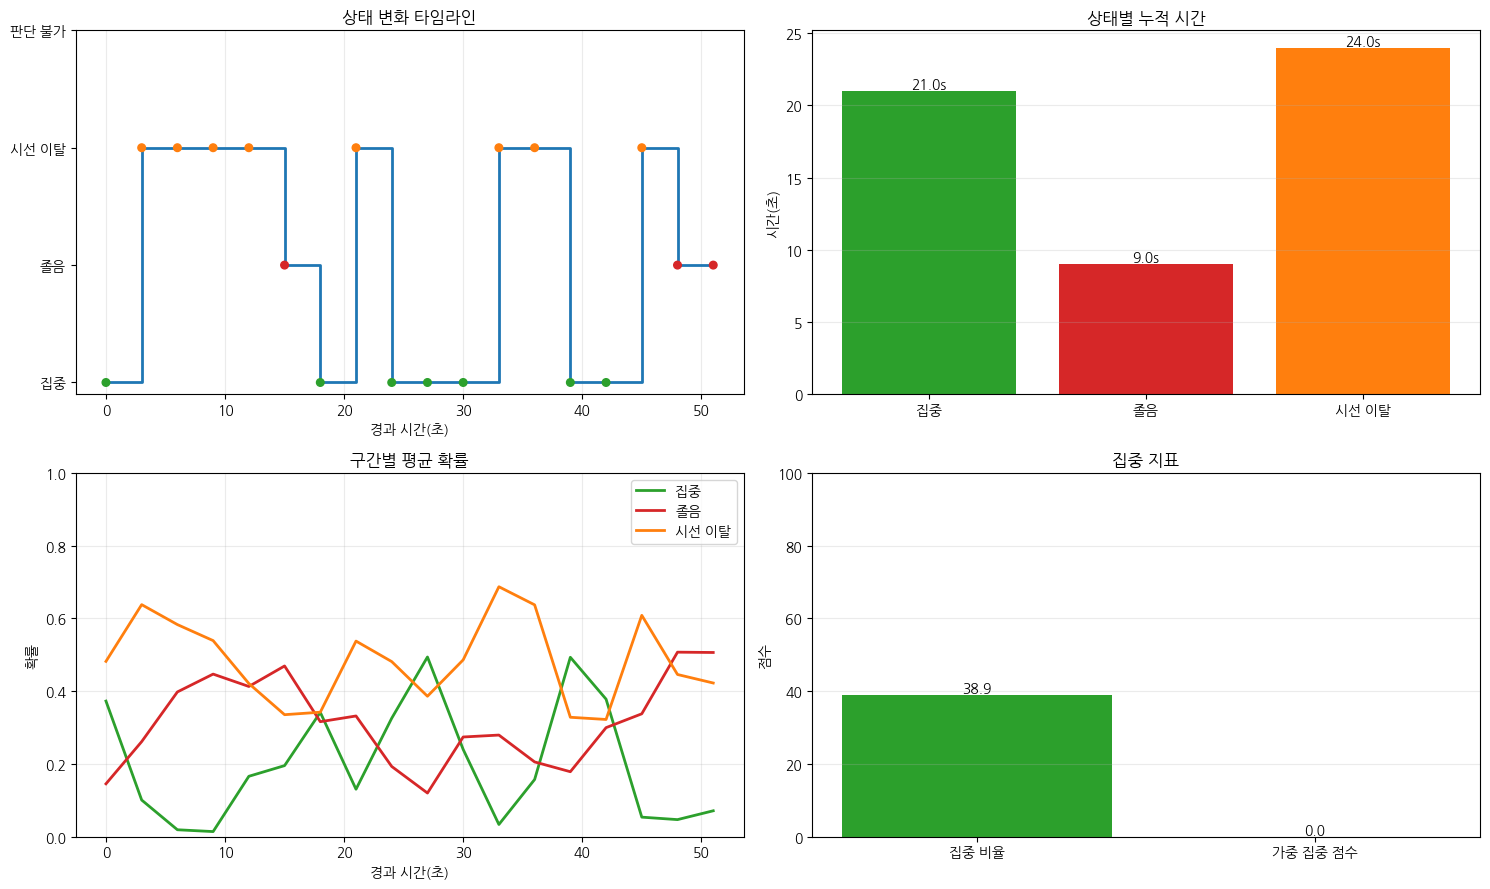

In [44]:
# Cell 5 code: post-run analysis report and visualization
import matplotlib.pyplot as plt
try:
    import koreanize_matplotlib
except ImportError:
    print("koreanize_matplotlib is not installed. Install it if Korean labels are not displayed correctly.")
from collections import Counter

STATE_COLORS = {
    "Attentive": "#2ca02c",
    "Drowsy": "#d62728",
    "LookingAway": "#ff7f0e",
    "Unknown": "#7f7f7f",
}
STATE_ORDER = ["Attentive", "Drowsy", "LookingAway", "Unknown"]
STATE_LABELS_KO = {
    "Attentive": "집중",
    "Drowsy": "졸음",
    "LookingAway": "시선 이탈",
    "Unknown": "판단 불가",
}
NON_ATTENTIVE_STATES = {"Drowsy", "LookingAway"}


def load_session_logs_for_report(db_path=DB_PATH, target_session_id=None):
    db_path = Path(db_path)
    if not db_path.exists():
        raise FileNotFoundError(f"DB file not found: {db_path}")

    with sqlite3.connect(db_path) as conn:
        conn.row_factory = sqlite3.Row
        if target_session_id is None:
            row = conn.execute(
                """
                SELECT session_id
                FROM class_sessions
                ORDER BY started_at DESC
                LIMIT 1
                """
            ).fetchone()
            if row is None:
                raise ValueError("No saved session found in DB.")
            target_session_id = row["session_id"]

        session = conn.execute(
            "SELECT * FROM class_sessions WHERE session_id = ?",
            (target_session_id,),
        ).fetchone()
        logs = conn.execute(
            """
            SELECT *
            FROM attention_logs
            WHERE session_id = ?
            ORDER BY id ASC
            """,
            (target_session_id,),
        ).fetchall()

    return target_session_id, session, logs


def format_time(seconds):
    minutes = int(seconds // 60)
    remain = seconds - minutes * 60
    return f"{minutes:02d}:{remain:04.1f}"


def build_state_runs(states, window_duration_sec):
    runs = []
    if not states:
        return runs

    start_index = 0
    current_state = states[0]
    for index, state in enumerate(states[1:], start=1):
        if state == current_state:
            continue
        runs.append({
            "state": current_state,
            "start_index": start_index,
            "end_index": index - 1,
            "count": index - start_index,
            "start_sec": start_index * window_duration_sec,
            "end_sec": index * window_duration_sec,
            "duration_sec": (index - start_index) * window_duration_sec,
        })
        start_index = index
        current_state = state

    runs.append({
        "state": current_state,
        "start_index": start_index,
        "end_index": len(states) - 1,
        "count": len(states) - start_index,
        "start_sec": start_index * window_duration_sec,
        "end_sec": len(states) * window_duration_sec,
        "duration_sec": (len(states) - start_index) * window_duration_sec,
    })
    return runs


def print_table(headers, rows):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        for idx, value in enumerate(row):
            widths[idx] = max(widths[idx], len(str(value)))

    line = "  ".join(str(header).ljust(widths[idx]) for idx, header in enumerate(headers))
    print(line)
    print("  ".join("-" * width for width in widths))
    for row in rows:
        print("  ".join(str(value).ljust(widths[idx]) for idx, value in enumerate(row)))


target_session_id = globals().get("session_id")
target_session_id, session_row, log_rows = load_session_logs_for_report(DB_PATH, target_session_id)

if not log_rows:
    raise ValueError(f"No attention_logs rows found for session: {target_session_id}")

states = [row["final_state"] for row in log_rows]
counts = Counter(states)
window_duration_sec = WINDOW_SIZE * SAMPLE_INTERVAL_SEC
total_windows = len(states)
total_analyzed_sec = total_windows * window_duration_sec

attentive_sec = counts.get("Attentive", 0) * window_duration_sec
drowsy_sec = counts.get("Drowsy", 0) * window_duration_sec
lookingaway_sec = counts.get("LookingAway", 0) * window_duration_sec
unknown_sec = counts.get("Unknown", 0) * window_duration_sec
known_sec = max(0.0, total_analyzed_sec - unknown_sec)
focus_ratio = attentive_sec / known_sec * 100.0 if known_sec else 0.0
focus_score = max(0.0, min(100.0, focus_ratio - (drowsy_sec / known_sec * 120.0 if known_sec else 0.0) - (lookingaway_sec / known_sec * 80.0 if known_sec else 0.0)))
transition_count = sum(1 for prev, curr in zip(states, states[1:]) if prev != curr)
runs = build_state_runs(states, window_duration_sec)
non_attentive_events = [run for run in runs if run["state"] in NON_ATTENTIVE_STATES]
longest_by_state = {
    state: max((run for run in runs if run["state"] == state), key=lambda run: run["duration_sec"], default=None)
    for state in STATE_ORDER
}

summary_rows = []
for state in STATE_ORDER:
    count = counts.get(state, 0)
    duration_sec = count * window_duration_sec
    ratio = count / total_windows * 100.0 if total_windows else 0.0
    summary_rows.append([STATE_LABELS_KO[state], count, f"{duration_sec:.1f}초", f"{ratio:.1f}%"])

print("세션 ID:", target_session_id)
if session_row is not None:
    print("시작 시각:", session_row["started_at"])
    print("종료 시각:", session_row["ended_at"])
print(f"분석 구간 수: {total_windows}개 (총 {total_analyzed_sec:.1f}초, 구간당 {window_duration_sec:.1f}초)")
print(f"집중 비율: {focus_ratio:.1f}%")
print(f"가중 집중 점수: {focus_score:.1f}/100")
print(f"상태 전환 횟수: {transition_count}회")

print("\n상태 요약")
print_table(["상태", "구간 수", "누적 시간", "비율"], summary_rows)

print("\n상태별 최장 연속 구간")
longest_rows = []
for state in STATE_ORDER:
    run = longest_by_state[state]
    if run is None:
        longest_rows.append([STATE_LABELS_KO[state], "0.0초", "-", 0])
    else:
        longest_rows.append([STATE_LABELS_KO[state], f"{run['duration_sec']:.1f}초", f"{format_time(run['start_sec'])}-{format_time(run['end_sec'])}", run["count"]])
print_table(["상태", "최장 지속", "시간 범위", "구간 수"], longest_rows)

print("\n비집중 이벤트")
if non_attentive_events:
    event_rows = [
        [
            index,
            STATE_LABELS_KO[run["state"]],
            f"{format_time(run['start_sec'])}-{format_time(run['end_sec'])}",
            f"{run['duration_sec']:.1f}초",
            run["count"],
        ]
        for index, run in enumerate(non_attentive_events, start=1)
    ]
    print_table(["#", "상태", "시간 범위", "지속 시간", "구간 수"], event_rows)
else:
    print("졸음 또는 시선 이탈 이벤트가 없습니다.")

timeline_x = [index * window_duration_sec for index in range(total_windows)]
TIMELINE_STATE_ORDER = ["Unknown", "Drowsy", "LookingAway", "Attentive"]
state_to_y = {state: idx for idx, state in enumerate(TIMELINE_STATE_ORDER)}
timeline_y = [state_to_y.get(state, state_to_y["Unknown"]) for state in states]
bar_states = [state for state in STATE_ORDER if counts.get(state, 0) > 0]
bar_durations = [counts[state] * window_duration_sec for state in bar_states]
bar_colors = [STATE_COLORS[state] for state in bar_states]

attentive_avg = [row["attentive_avg"] or 0.0 for row in log_rows]
drowsy_avg = [row["drowsy_avg"] or 0.0 for row in log_rows]
lookingaway_avg = [row["lookingaway_avg"] or 0.0 for row in log_rows]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

axes[0].step(timeline_x, timeline_y, where="post", color="#1f77b4", linewidth=2)
axes[0].scatter(timeline_x, timeline_y, c=[STATE_COLORS.get(state, "#7f7f7f") for state in states], s=30, zorder=3)
axes[0].set_title("상태 변화 타임라인")
axes[0].set_xlabel("경과 시간(초)")
axes[0].set_yticks(range(len(TIMELINE_STATE_ORDER)))
axes[0].set_yticklabels([STATE_LABELS_KO[state] for state in TIMELINE_STATE_ORDER])
axes[0].grid(True, axis="x", alpha=0.25)

bar_labels_ko = [STATE_LABELS_KO[state] for state in bar_states]
axes[1].bar(bar_labels_ko, bar_durations, color=bar_colors)
axes[1].set_title("상태별 누적 시간")
axes[1].set_ylabel("시간(초)")
axes[1].grid(True, axis="y", alpha=0.25)
for index, value in enumerate(bar_durations):
    axes[1].text(index, value, f"{value:.1f}s", ha="center", va="bottom")

axes[2].plot(timeline_x, attentive_avg, label="집중", color=STATE_COLORS["Attentive"], linewidth=2)
axes[2].plot(timeline_x, drowsy_avg, label="졸음", color=STATE_COLORS["Drowsy"], linewidth=2)
axes[2].plot(timeline_x, lookingaway_avg, label="시선 이탈", color=STATE_COLORS["LookingAway"], linewidth=2)
axes[2].set_title("구간별 평균 확률")
axes[2].set_xlabel("경과 시간(초)")
axes[2].set_ylabel("확률")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.25)
axes[2].legend()

score_labels = ["집중 비율", "가중 집중 점수"]
score_values = [focus_ratio, focus_score]
axes[3].bar(score_labels, score_values, color=["#2ca02c", "#1f77b4"])
axes[3].set_title("집중 지표")
axes[3].set_ylim(0, 100)
axes[3].set_ylabel("점수")
axes[3].grid(True, axis="y", alpha=0.25)
for index, value in enumerate(score_values):
    axes[3].text(index, value, f"{value:.1f}", ha="center", va="bottom")

fig.tight_layout()
plt.show()
